In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from backtest_engine import *
from pathlib import Path
from typing import Optional, List

In [109]:
def load_ticker_data(
    ticker: str,
    data_dir: str = "./data",
    tickers: Optional[List[str]] = None,
) -> pd.DataFrame:
    """
    Charge toutes les données 1-min OHLCV pour un ticker donné.

    Convention fichiers (identique au DataLoader de l'engine) :
        data_dir/
          Yahoo_1m_DD_MM_YY/
            df_{TICKER}_{YYYYMMDD}_{HHMMSS}.pkl

    Parameters
    ----------
    ticker   : e.g. "^GSPC", "AAPL", "GC=F"
    data_dir : racine des données (défaut "./data")
    tickers  : si fourni, charge plusieurs tickers -> dict {ticker: df}

    Returns
    -------
    pd.DataFrame avec index DatetimeIndex UTC et colonnes open/high/low/close/volume
    """
    if tickers is not None:
        return {t: load_ticker_data(t, data_dir) for t in tickers}

    root = Path(data_dir)
    daily_frames = []

    for folder in sorted(root.glob("Yahoo_1m_*")):
        if not folder.is_dir():
            continue
        matches = list(folder.glob(f"df_{ticker}_*.pkl"))
        if not matches:
            continue
        try:
            df_day = _load_one_day(matches[0])
            if df_day is not None and len(df_day) > 0:
                daily_frames.append(df_day)
        except Exception as e:
            print(f"[load_ticker_data] Warning - skipping {matches[0].name}: {e}")

    if not daily_frames:
        raise FileNotFoundError(
            f"[load_ticker_data] Aucune donnée pour '{ticker}' dans {root}"
        )

    df = pd.concat(daily_frames).sort_index()
    df = df[~df.index.duplicated(keep="first")]

    print(
        f"[load_ticker_data] {ticker:12s} | "
        f"{df.index[0].date()} -> {df.index[-1].date()} | "
        f"{len(df):,} bars | "
        f"{df.index.normalize().nunique()} jours"
    )
    return df


def _load_one_day(path: Path) -> Optional[pd.DataFrame]:
    """Parse un fichier pickle journalier (MultiIndex ou flat columns)."""
    raw = pd.read_pickle(path)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [price.lower() for price, _ in raw.columns]
    else:
        raw.columns = [c.lower() for c in raw.columns]

    raw = raw.rename(columns={"adj close": "adj_close"})

    required = {"open", "high", "low", "close", "volume"}
    missing  = required - set(raw.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes {missing} dans {path.name}")

    df = raw[["open", "high", "low", "close", "volume"]].copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)
    elif df.index.tz is None:
        df.index = df.index.tz_localize("UTC")

    df["volume"] = df["volume"].fillna(0)
    return df.dropna(subset=["open", "high", "low", "close"])

# Petite paranthèse: code pour débuter le backtest

In [ ]:
class MyStrategy(BaseStrategy):
    def fit(self, df_is: pd.DataFrame) -> None:
        # Calibration sur les données In-Sample
        # Ex: calculer un seuil optimal, entraîner un modèle...
        self.window = 20

    def generate_signal(self, bar: pd.Series, state: dict) -> int:
        # Retourne -1 (short), 0 (flat), ou +1 (long)
        hist = state.setdefault("hist", [])
        hist.append(bar["close"])
        if len(hist) < self.window:
            return 0
        ma = sum(hist[-self.window:]) / self.window
        return 1 if bar["close"] > ma else -1

In [ ]:
cfg = Config(
    tickers    = ["AAPL", "^GSPC"],
    data_dir   = "./data",          # dossier avec tes pickles Yahoo
    is_months  = 5,                 # mois de calibration
    oos_months = 1,                 # mois d'évaluation

    # Optionnel - risk management
    sizing_method    = "volatility",  # "fixed" | "volatility" | "atr"
    stop_loss        = 0.005,         # 0.5% adverse move → ferme
    take_profit      = 0.01,          # 1% favorable → ferme
    daily_loss_limit = 0.02,          # 2% perte journalière → stop trading

    output_dir = "./results",
    plot       = True,
)

In [ ]:
results = run_backtest(strategy=MyStrategy(), cfg=cfg)

# II. Statistical Arbitrage intraday or Pairs trading

In [122]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations

# ═══════════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ═══════════════════════════════════════════════════════════════════

MARKET_GROUPS = {
    "US_Indices":  ['^GSPC', '^DJI', '^RUT', 'QQQ'],
    "US_Tech":     ['AMD', 'NVDA', 'GOOG', 'MSFT', 'AAPL', 'AMZN'],
    "US_Other":    ['SMTC', 'GM', 'BBY', 'GME', 'POET', 'HSAI',
                    'AMGN', 'UNH', 'OPTT', 'ZENA', 'TM', 'PSTX', 'STLA'],
    "US_EV":       ['TSLA', 'TM', 'STLA'],
    "Commodities": ['GC=F', 'CL=F', 'BZ=F', 'NG=F', 'ZS=F'],
    "Forex":       ['EURUSD=X', 'JPYUSD=X', 'GBPUSD=X'],
}

ALPHA        = 0.05
MIN_BARS     = 100
MAX_HALFLIFE = 500   # bars 1-min (~1.5 jours de trading)
MIN_HALFLIFE = 5

# ═══════════════════════════════════════════════════════════════════
# 2. CHARGEMENT
# ═══════════════════════════════════════════════════════════════════

all_tickers = list({t for group in MARKET_GROUPS.values() for t in group})

raw, failed = {}, []
for t in all_tickers:
    try:
        raw[t] = load_ticker_data(t, data_dir="./data")["close"]
    except FileNotFoundError:
        failed.append(t)

if failed:
    print(f"[Warning] Tickers non trouvés : {failed}")

# ═══════════════════════════════════════════════════════════════════
# 3. HELPERS
# ═══════════════════════════════════════════════════════════════════

def align_pair(a: str, b: str) -> pd.DataFrame:
    """Inner join strict sur index commun 1-min."""
    return pd.DataFrame({"a": raw[a], "b": raw[b]}).dropna()


def compute_halflife(spread: pd.Series) -> float:
    """Half-life Ornstein-Uhlenbeck via régression OLS."""
    lag  = spread.shift(1).dropna()
    diff = spread.diff().dropna()
    ols  = sm.OLS(diff, sm.add_constant(lag)).fit()
    lam  = ols.params[1]
    return -np.log(2) / lam if lam < 0 else np.inf


def analyze_pair(a: str, b: str) -> dict | None:
    if a not in raw or b not in raw:
        return None

    common = align_pair(a, b)
    if len(common) < MIN_BARS:
        return None

    s_a = common["a"].values
    s_b = common["b"].values

    # ── hedge ratio : passer un DataFrame pour forcer le nom "const" ──
    X           = sm.add_constant(pd.Series(s_b, name=a))
    model       = sm.OLS(s_a, X).fit()
    hedge_ratio = model.params.iloc[1]          # iloc au lieu de [1]
    spread      = common["a"] - hedge_ratio * common["b"]

    # ── ADF ───────────────────────────────────────────────────────────
    adf_pval = adfuller(spread)[1]

    # ── Half-life ─────────────────────────────────────────────────────
    lag  = spread.shift(1).dropna()
    diff = spread.diff().dropna()
    X2   = sm.add_constant(pd.Series(lag.values, name="lag"))
    ols  = sm.OLS(diff.values, X2).fit()
    lam  = ols.params.iloc[1]
    half_life = -np.log(2) / lam if lam < 0 else np.inf

    tradeable = (adf_pval < ALPHA) and (MIN_HALFLIFE < half_life < MAX_HALFLIFE)

    return {
        "asset_1":    a,
        "asset_2":    b,
        "n_bars":     len(common),
        "hedge_ratio": round(hedge_ratio, 4),
        "adf_pval":   round(adf_pval,    6),
        "half_life":  round(half_life,   1),
        "tradeable":  tradeable,
    }

# ═══════════════════════════════════════════════════════════════════
# 4. SCREENING : COINTÉGRATION PAR GROUPE
# ═══════════════════════════════════════════════════════════════════

coint_results = []

for group_name, tickers in MARKET_GROUPS.items():
    available = [t for t in tickers if t in raw]
    if len(available) < 2:
        continue

    # aligner tout le groupe sur index commun
    group_data = pd.DataFrame({t: raw[t] for t in available}).dropna()

    if len(group_data) < MIN_BARS:
        print(f"[{group_name}] Seulement {len(group_data)} bars communs — skip.")
        continue

    print(f"\n[{group_name}] {len(group_data):,} bars | tickers : {available}")

    for a, b in combinations(available, 2):
        try:
            _, pvalue, _ = coint(group_data[a].values, group_data[b].values)
            if pvalue < ALPHA:
                coint_results.append({
                    "group": group_name, "asset_1": a,
                    "asset_2": b, "coint_pval": round(pvalue, 6),
                })
        except Exception as e:
            print(f"  [coint] Erreur ({a}, {b}) : {e}")

coint_df = pd.DataFrame(coint_results).sort_values("coint_pval").reset_index(drop=True)
print(f"\n{'='*55}")
print(f"Paires cointégrées (p < {ALPHA}) : {len(coint_df)}")
print(coint_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════
# 5. DIAGNOSTIC COMPLET SUR LES PAIRES RETENUES
# ═══════════════════════════════════════════════════════════════════

diagnostics = []
for _, row in coint_df.iterrows():
    diag = analyze_pair(row["asset_1"], row["asset_2"])
    if diag:
        diag["coint_pval"] = row["coint_pval"]
        diag["group"]      = row["group"]
        diagnostics.append(diag)

diag_df = (
    pd.DataFrame(diagnostics)
    .sort_values(["tradeable", "half_life"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"\n{'='*55}")
print("DIAGNOSTIC COMPLET\n")
print(diag_df[[
    "group", "asset_1", "asset_2", "n_bars",
    "hedge_ratio", "coint_pval", "adf_pval", "half_life", "tradeable"
]].to_string(index=False))

print(f"\n{'='*55}")
print(f"Paires tradeables : {diag_df['tradeable'].sum()}/{len(diag_df)}\n")
print(diag_df[diag_df["tradeable"]][[
    "group", "asset_1", "asset_2", "hedge_ratio", "half_life"
]].to_string(index=False))

[load_ticker_data] GBPUSD=X     | 2025-01-06 -> 2025-02-17 | 11,220 bars | 29 jours
[load_ticker_data] SMTC         | 2025-01-06 -> 2025-07-31 | 51,695 bars | 142 jours
[load_ticker_data] UNH          | 2025-01-07 -> 2025-07-31 | 54,402 bars | 141 jours
[load_ticker_data] AMZN         | 2025-01-06 -> 2025-07-31 | 54,833 bars | 142 jours
[load_ticker_data] NVDA         | 2025-01-06 -> 2025-07-31 | 54,839 bars | 142 jours
[load_ticker_data] EURUSD=X     | 2025-01-06 -> 2025-02-17 | 11,219 bars | 29 jours
[load_ticker_data] BBY          | 2025-01-06 -> 2025-07-31 | 54,501 bars | 142 jours
[load_ticker_data] GME          | 2025-01-06 -> 2025-07-31 | 54,774 bars | 142 jours
[load_ticker_data] GOOG         | 2025-01-06 -> 2025-07-31 | 53,663 bars | 139 jours
[load_ticker_data] GC=F         | 2025-01-06 -> 2025-02-17 | 11,169 bars | 29 jours
[load_ticker_data] GM           | 2025-01-06 -> 2025-07-31 | 54,835 bars | 142 jours
[load_ticker_data] STLA         | 2025-01-06 -> 2025-07-31 | 54,657 

In [112]:
class PairTradingStrategy(BaseStrategy):
    """
    Statistical arbitrage on a cointegrated pair.

    Leg1 = ticker managed by Backtester
    Leg2 = loaded internally from data_dir

    Signal logic
    ------------
    spread_t  = price1_t - beta_t * price2_t
    z_score_t = (spread_t - mean(spread[-z_window:])) / std(spread[-z_window:])

    Entry : |z_score| > z_entry
    Exit  : z_score crosses z_exit (default 0)

    Beta estimation
    ---------------
    Re-estimated bar-by-bar via rolling OLS over beta_window bars.
    Falls back to beta=1.0 during warm-up.

    Z-score estimation
    ------------------
    Rolling mean/std over z_window bars — fully causal, no IS leakage.
    """

    def __init__(
        self,
        leg2_ticker: str,
        cfg:         Config,
        z_entry:     float = 2.0,
        z_exit:      float = 0.0,
        z_window:    int   = 60,
        beta_window: int   = 390,
    ):
        self.leg2_ticker = leg2_ticker
        self.cfg         = cfg
        self.z_entry     = z_entry
        self.z_exit      = z_exit
        self.z_window    = z_window
        self.beta_window = beta_window
        self._leg2_data  = None   # full close series, loaded in fit()

    def fit(self, df_is: pd.DataFrame) -> None:
        # Load full leg2 series (IS + OOS) — only closes needed
        loader           = DataLoader(self.cfg)
        df2_full         = loader.load(self.leg2_ticker)
        self._leg2_data  = df2_full["close"]

        print(
            f"  [PairTrading] {df_is.index[0].date()} -> IS end | "
            f"leg2={self.leg2_ticker} | "
            f"beta_window={self.beta_window} | z_window={self.z_window}"
        )

    def generate_signal(self, bar: pd.Series, state: dict) -> int:
        ts = bar.name
        if ts not in self._leg2_data.index:
            return 0

        price1 = bar["close"]
        price2 = float(self._leg2_data.loc[ts])

        # ── Rolling buffers ───────────────────────────────────────────────
        buf1 = state.setdefault("buf1", [])
        buf2 = state.setdefault("buf2", [])
        buf1.append(price1)
        buf2.append(price2)

        # ── Rolling beta (OLS) ────────────────────────────────────────────
        if len(buf1) >= self.beta_window:
            x    = np.array(buf2[-self.beta_window:], dtype=float)
            y    = np.array(buf1[-self.beta_window:], dtype=float)
            x_dm = x - x.mean()
            var  = np.dot(x_dm, x_dm)
            beta = np.dot(x_dm, y - y.mean()) / var if var != 0 else state.get("beta", 1.0)
        else:
            beta = state.get("beta", 1.0)
        state["beta"] = beta

        # ── Rolling z-score ───────────────────────────────────────────────
        spread_buf = state.setdefault("spread_buf", [])
        spread_buf.append(price1 - beta * price2)

        if len(spread_buf) < self.z_window:
            return 0

        window  = np.array(spread_buf[-self.z_window:], dtype=float)
        sigma   = window.std()
        z_score = (spread_buf[-1] - window.mean()) / (sigma + 1e-10)
        state["z_score"] = z_score

        position = state.get("position", 0)

        # ── Entry ─────────────────────────────────────────────────────────
        if position == 0:
            if z_score >  self.z_entry:
                state["position"] = -1
                return -1   # spread too high → short leg1, long leg2
            if z_score < -self.z_entry:
                state["position"] =  1
                return  1   # spread too low  → long leg1, short leg2

        # ── Exit ──────────────────────────────────────────────────────────
        elif position == 1 and z_score >= self.z_exit:
            state["position"] = 0
            return 0
        elif position == -1 and z_score <= self.z_exit:
            state["position"] = 0
            return 0

        return position


  GOOG
[DataLoader] GOOG         - 2025-01-06 -> 2025-07-31  (53,663 bars, 139 days)
           IS  : 2025-01-06 -> 2025-05-30 (97 days)
           OOS : 2025-06-02 -> 2025-07-31 (42 days)
  [Backtester] Fitting strategy on IS data ...
[DataLoader] AMD          - 2025-01-06 -> 2025-07-31  (54,832 bars, 142 days)
  [PairTrading] 2025-01-06 -> IS end | leg2=AMD | beta_window=60 | z_window=15
  [Backtester] IS replay - 97 days | avg 34.7 trades/day | net return: -64.19%
  [Backtester] OOS replay - 42 days | avg 33.4 trades/day | net return: -28.84%

  NVDA
[DataLoader] NVDA         - 2025-01-06 -> 2025-07-31  (54,839 bars, 142 days)
           IS  : 2025-01-06 -> 2025-05-30 (100 days)
           OOS : 2025-06-02 -> 2025-07-31 (42 days)
  [Backtester] Fitting strategy on IS data ...
[DataLoader] AMZN         - 2025-01-06 -> 2025-07-31  (54,833 bars, 142 days)
  [PairTrading] 2025-01-06 -> IS end | leg2=AMZN | beta_window=60 | z_window=15
  [Backtester] IS replay - 100 days | avg 34.9 trad

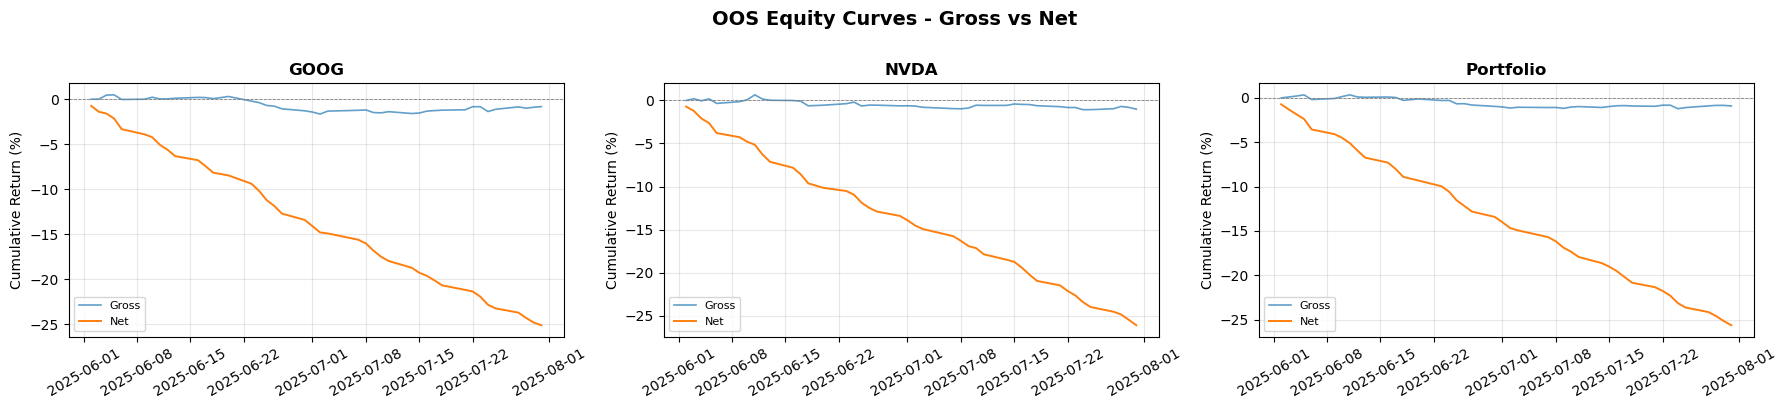

[Reporter] Saved -> results\equity_curves.png


In [127]:
cfg = Config(
    tickers    = ["GOOG", "NVDA"],  # les deux leg1
    data_dir   = "./data",
    is_months  = 5,
    oos_months = 1,
    stop_loss        = 0.05,
    take_profit      = 0.1,
    daily_loss_limit = 0.1,
    output_dir = "./results",
    plot       = True,
)

results = run_backtest(
    strategy = {
        "NVDA": PairTradingStrategy(leg2_ticker="AMZN", cfg=cfg, z_entry=1.0, z_exit=0, z_window=15, beta_window=60),
        "GOOG": PairTradingStrategy(leg2_ticker="AMD",  cfg=cfg, z_entry=1.0, z_exit=0, z_window=15, beta_window=60),
    },
    cfg = cfg,
)